In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS_PUBLIC = PROJECT_ROOT / "artifacts" / "public"
DATA_PUBLIC = PROJECT_ROOT / "data" / "public"
MODELS_PUBLIC = PROJECT_ROOT / "models" / "public"

# Notebook de Feature Engineering

En este notebook trabajamos con `dataset_modelo_proveedor_v2_candidates.csv` para hacer **feature engineering** y evaluar KNN en un problema de clasificación binaria (`target_elegido`).

Cada fila representa un par **(evento de compra, proveedor candidato)**, por lo que el objetivo es estimar la probabilidad de que ese candidato sea el proveedor finalmente elegido.

Usamos validación temporal y comparamos contra un baseline `Dummy` para comprobar si las nuevas variables aportan señal real.


## Librerías

In [2]:
# Librerías

import pandas as pd
pd.set_option("display.max_columns", None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
from pathlib import Path

# Sube de notebooks/ a la raíz del repo

sys.path.append(str(Path.cwd().parent))

# Importamos funciones

import src.ml.shared.functions as fc

%matplotlib inline 
%load_ext autoreload
%autoreload 2

## Cargamos dataset

In [3]:
df = fc.load_data("dataset_modelo_proveedor_v2_candidates.csv")

## EDA

In [4]:
df.head()

,event_id,fecha_evento,albaran_id,linea_id,producto_canonico,terminal_compra,proveedor_elegido_real,proveedor_candidato,coste_min_dia_proveedor,rank_coste_dia_producto,terminales_cubiertos,observaciones_oferta,candidatos_evento_count,coste_min_evento,coste_max_evento,spread_coste_evento,delta_vs_min_evento,ratio_vs_min_evento,litros_evento,precio_unitario_evento,importe_total_evento,dia_semana,mes,fin_mes,blocked_by_rule_candidate,block_reason_candidate,target_elegido,v2_run_id,v2_ts_utc
0,EVENT_8C109313E315,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_0CBDAF1D1C30,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_020,795.34,1.0,4.0,4.0,13,795.34,814.53,19.19,0.00,1.000000,9999,0.79428,7942.01,0,4,0,1,RULE_002,0,RUN_556F2D793E50,2030-03-06T12:21:19Z
1,EVENT_8C109313E315,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_0CBDAF1D1C30,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_061,796.34,2.0,5.0,5.0,13,795.34,814.53,19.19,1.00,1.001257,9999,0.79428,7942.01,0,4,0,0,NaN,0,RUN_556F2D793E50,2030-03-06T12:21:19Z
2,EVENT_8C109313E315,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_0CBDAF1D1C30,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_001,796.62,3.0,1.0,1.0,13,795.34,814.53,19.19,1.28,1.001609,9999,0.79428,7942.01,0,4,0,0,NaN,0,RUN_556F2D793E50,2030-03-06T12:21:19Z
3,EVENT_8C109313E315,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_0CBDAF1D1C30,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_003,797.34,4.0,4.0,4.0,13,795.34,814.53,19.19,2.00,1.002515,9999,0.79428,7942.01,0,4,0,1,RULE_001,0,RUN_556F2D793E50,2030-03-06T12:21:19Z
4,EVENT_8C109313E315,2021-04-03,ALBARAN_D7E0C13BBBBC,LINE_0CBDAF1D1C30,PRODUCT_002,TERMINAL_001,SUPPLIER_009,SUPPLIER_013,798.74,5.0,4.0,4.0,13,795.34,814.53,19.19,3.40,1.004275,9999,0.79428,7942.01,0,4,0,0,NaN,0,RUN_556F2D793E50,2030-03-06T12:21:19Z


In [5]:
df.dtypes

event_id                      object
fecha_evento                  object
albaran_id                    object
linea_id                      object
producto_canonico             object
terminal_compra               object
proveedor_elegido_real        object
proveedor_candidato           object
coste_min_dia_proveedor      float64
rank_coste_dia_producto      float64
terminales_cubiertos         float64
observaciones_oferta         float64
candidatos_evento_count        int64
coste_min_evento             float64
coste_max_evento             float64
spread_coste_evento          float64
delta_vs_min_evento          float64
ratio_vs_min_evento          float64
litros_evento                  int64
precio_unitario_evento       float64
importe_total_evento         float64
dia_semana                     int64
mes                            int64
fin_mes                        int64
blocked_by_rule_candidate      int64
block_reason_candidate        object
target_elegido                 int64
v

In [6]:
df.shape

(155946, 29)

In [7]:
df.isna().sum()

event_id                          0
fecha_evento                      0
albaran_id                        0
linea_id                          0
producto_canonico                 0
terminal_compra                   0
proveedor_elegido_real            0
proveedor_candidato               0
coste_min_dia_proveedor           0
rank_coste_dia_producto           0
terminales_cubiertos              0
observaciones_oferta              0
candidatos_evento_count           0
coste_min_evento                  0
coste_max_evento                  0
spread_coste_evento               0
delta_vs_min_evento               0
ratio_vs_min_evento               0
litros_evento                     0
precio_unitario_evento            0
importe_total_evento              0
dia_semana                        0
mes                               0
fin_mes                           0
blocked_by_rule_candidate         0
block_reason_candidate       127465
target_elegido                    0
v2_run_id                   

## Subset de datos para entrenamiento

In [8]:
df_model = fc.df_model_knn_feature(df)

In [9]:
train, test, _ = fc.split_temporal_feature(df_model)

In [10]:
feature_cols_num, feature_cols_cat, target_col = fc.get_feature_columns_v2()

In [11]:
train_num = train[feature_cols_num].apply(pd.to_numeric, errors="coerce")
corr = train_num.corr(numeric_only=True)

display(corr)

high_corr = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
)
high_corr.columns = ["var1", "var2", "corr"]
high_corr = high_corr[high_corr["corr"].abs() >= 0.9].sort_values("corr", ascending=False)
display(high_corr)


,coste_min_dia_proveedor,rank_coste_dia_producto,terminales_cubiertos,observaciones_oferta,candidatos_evento_count,coste_min_evento,coste_max_evento,spread_coste_evento,delta_vs_min_evento,ratio_vs_min_evento,litros_evento,dia_semana,mes,fin_mes
coste_min_dia_proveedor,1.000000,0.021987,-0.138360,-0.138133,-0.121919,0.954684,0.848958,0.129345,0.256093,0.000905,-0.063436,0.015687,-0.009988,0.000645
rank_coste_dia_producto,0.021987,1.000000,-0.006316,-0.009250,0.252618,-0.031490,-0.026949,-0.002455,0.176084,0.007966,-0.014396,-0.011441,-0.008351,-0.017753
terminales_cubiertos,-0.138360,-0.006316,1.000000,0.995462,0.064161,-0.132250,-0.118013,-0.018621,-0.034916,-0.006650,-0.009329,0.005559,0.055317,-0.008571
observaciones_oferta,-0.138133,-0.009250,0.995462,1.000000,0.066309,-0.131920,-0.117744,-0.018618,-0.035223,-0.006884,-0.009560,0.006097,0.053115,-0.007865
candidatos_evento_count,-0.121919,0.252618,0.064161,0.066309,1.000000,-0.120946,-0.105190,-0.012327,-0.016441,-0.025600,-0.053706,-0.046155,-0.002895,-0.059724
coste_min_evento,0.954684,-0.031490,-0.132250,-0.131920,-0.120946,1.000000,0.813313,0.004961,-0.043208,-0.132228,-0.065389,0.006068,-0.015132,-0.001185
coste_max_evento,0.848958,-0.026949,-0.118013,-0.117744,-0.105190,0.813313,1.000000,0.585854,0.208234,-0.001435,-0.054878,0.014155,-0.015781,-0.003381
spread_coste_evento,0.129345,-0.002455,-0.018621,-0.018618,-0.012327,0.004961,0.585854,1.000000,0.418077,0.181713,-0.003240,0.015876,-0.006045,-0.004161
delta_vs_min_evento,0.256093,0.176084,-0.034916,-0.035223,-0.016441,-0.043208,0.208234,0.418077,1.000000,0.432506,-0.000564,0.032950,0.015618,0.006014
ratio_vs_min_evento,0.000905,0.007966,-0.006650,-0.006884,-0.025600,-0.132228,-0.001435,0.181713,0.432506,1.000000,0.011213,0.049282,-0.022988,-0.006649


,var1,var2,corr
28,terminales_cubiertos,observaciones_oferta,0.995462
41,observaciones_oferta,terminales_cubiertos,0.995462
4,coste_min_dia_proveedor,coste_min_evento,0.954684
65,coste_min_evento,coste_min_dia_proveedor,0.954684


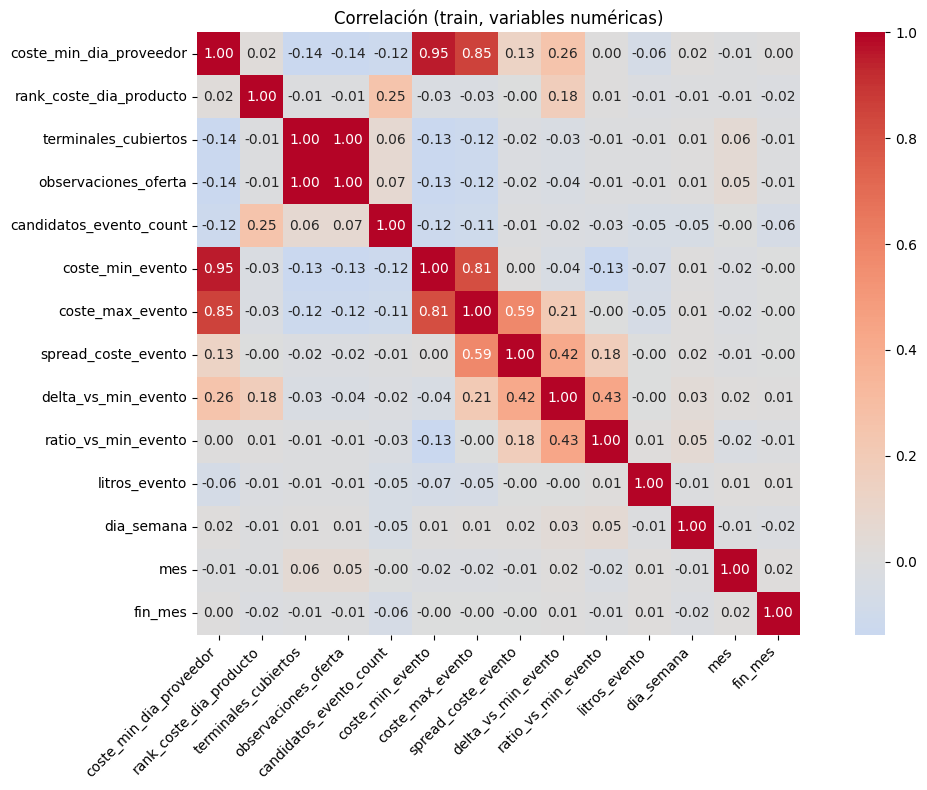

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlación (train, variables numéricas)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [13]:
#feature_cols_num = [
 #   "coste_min_dia_proveedor",
  #  "rank_coste_dia_producto",
   # "terminales_cubiertos",
    #"candidatos_evento_count",
#    "coste_max_evento",
 #   "spread_coste_evento",
  #  "delta_vs_min_evento",
   # "ratio_vs_min_evento",
#    "litros_evento",
 #   "dia_semana",
  #  "mes",
   # "fin_mes"
#]
# Ajuste por colinealidad (train):
# - quitamos `observaciones_oferta` por alta correlación con `terminales_cubiertos` (~0.995)
# - quitamos `coste_min_evento` por alta correlación con `coste_min_dia_proveedor` (~0.955)

# Dejo la celda por trazabilidad pero no se ejecutará dado que empeoró los resultados.

In [14]:
X_train, X_test, y_train, y_test = fc.dummificar_train_test(train, test, feature_cols_num, feature_cols_cat)

In [15]:
chosen_k = 21
knn_acc = fc.entrenar_knn(X_train, X_test, y_train, y_test, chosen_k)
print(f"KNN Accuracy (k={chosen_k}): {knn_acc:.4f}")


KNN Accuracy (k=21): 0.8744


In [16]:
# Celda reservada (sin uso).
# En Day 02 evitamos sweep/tuning para no duplicar el trabajo de Day 04.
pass


In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

# 1) Baseline Dummy (referencia)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== DUMMY ===")
print("accuracy:", round(accuracy_score(y_test, y_pred_dummy), 4))
print("balanced_accuracy:", round(balanced_accuracy_score(y_test, y_pred_dummy), 4))
print("f1_clase_1:", round(f1_score(y_test, y_pred_dummy, pos_label=1, zero_division=0), 4))
print(classification_report(y_test, y_pred_dummy, digits=4, zero_division=0))

# 2) KNN con k fijo definido arriba
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=chosen_k, n_jobs=-1))
])
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(f"\n=== KNN (k={chosen_k}) ===")
print("accuracy:", round(accuracy_score(y_test, y_pred_knn), 4))
print("balanced_accuracy:", round(balanced_accuracy_score(y_test, y_pred_knn), 4))
print("f1_clase_1:", round(f1_score(y_test, y_pred_knn, pos_label=1, zero_division=0), 4))
print(classification_report(y_test, y_pred_knn, digits=4, zero_division=0))

=== DUMMY ===
accuracy: 0.8737
balanced_accuracy: 0.5
f1_clase_1: 0.0
              precision    recall  f1-score   support

           0     0.8737    1.0000    0.9326     18219
           1     0.0000    0.0000    0.0000      2633

    accuracy                         0.8737     20852
   macro avg     0.4369    0.5000    0.4663     20852
weighted avg     0.7634    0.8737    0.8148     20852




=== KNN (k=21) ===
accuracy: 0.8744
balanced_accuracy: 0.7546
f1_clase_1: 0.5444
              precision    recall  f1-score   support

           0     0.9398    0.9149    0.9272     18219
           1     0.5022    0.5944    0.5444      2633

    accuracy                         0.8744     20852
   macro avg     0.7210    0.7546    0.7358     20852
weighted avg     0.8845    0.8744    0.8788     20852



In [18]:
import pandas as pd

# 1) Entrenar modelo final con k fijo de esta fase (sin tuning)
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=chosen_k, n_jobs=-1))
])
best_model.fit(X_train, y_train)

# 2) Probabilidad de clase positiva (ser elegido)
proba_test = best_model.predict_proba(X_test)
idx_pos = list(best_model.named_steps["knn"].classes_).index(1)
proba_pos = proba_test[:, idx_pos]

# 3) Recuperar test base con event_id + proveedor_candidato
test_eval = test.copy().reset_index(drop=True)
test_eval["score_elegido"] = proba_pos
test_eval["target_elegido"] = y_test.values

# 4) Ranking por evento
test_eval = test_eval.sort_values(["event_id", "score_elegido"], ascending=[True, False])
test_eval["rank_pred"] = test_eval.groupby("event_id").cumcount() + 1

# 5) Métricas Top-1 / Top-2
top1_hit = (
    test_eval[test_eval["rank_pred"] == 1]
    .groupby("event_id")["target_elegido"]
    .max()
    .mean()
)

top2_hit = (
    test_eval[test_eval["rank_pred"] <= 2]
    .groupby("event_id")["target_elegido"]
    .max()
    .mean()
)

print("Top-1 hit rate:", round(top1_hit, 4))
print("Top-2 hit rate:", round(top2_hit, 4))

# 6) Muestra de recomendaciones
cols_show = [
    "event_id", "fecha_evento", "producto_canonico",
    "proveedor_candidato", "score_elegido", "rank_pred", "target_elegido"
]

print("\n=== Ejemplo Top-2 por evento (primeros 10 eventos) ===")
sample_events = test_eval["event_id"].drop_duplicates().head(10)
display(
    test_eval[test_eval["event_id"].isin(sample_events) & (test_eval["rank_pred"] <= 2)][cols_show]
    .sort_values(["event_id", "rank_pred"])
)

# (Opcional) guardar reporte para revisión
# test_eval.to_csv("artifacts/public/day02_topk_eval_sample.csv", index=False)


Top-1 hit rate: 0.5218
Top-2 hit rate: 0.7858

=== Ejemplo Top-2 por evento (primeros 10 eventos) ===


,event_id,fecha_evento,producto_canonico,proveedor_candidato,score_elegido,rank_pred,target_elegido
15405,EVENT_001E84032733,2029-06-16,PRODUCT_003,SUPPLIER_009,0.714286,1,0
15407,EVENT_001E84032733,2029-06-16,PRODUCT_003,SUPPLIER_025,0.238095,2,0
20458,EVENT_003CCE93DDDB,2029-07-18,PRODUCT_003,SUPPLIER_009,0.142857,1,1
20450,EVENT_003CCE93DDDB,2029-07-18,PRODUCT_003,SUPPLIER_004,0.000000,2,0
8110,EVENT_0042710C9C0D,2029-04-24,PRODUCT_003,SUPPLIER_009,0.952381,1,1
8106,EVENT_0042710C9C0D,2029-04-24,PRODUCT_003,SUPPLIER_025,0.333333,2,0
9213,EVENT_006E91B098BC,2028-03-22,PRODUCT_002,SUPPLIER_007,0.666667,1,0
9215,EVENT_006E91B098BC,2028-03-22,PRODUCT_002,SUPPLIER_009,0.380952,2,1
13528,EVENT_0082D7C58268,2028-04-26,PRODUCT_003,SUPPLIER_009,0.761905,1,1
13529,EVENT_0082D7C58268,2028-04-26,PRODUCT_003,SUPPLIER_050,0.714286,2,0


## CONCLUSIONES (Day 02 · Feature Engineering sobre V2)

- El `feature engineering` sobre `dataset_modelo_proveedor_v2_candidates.csv` mejora claramente el rendimiento de KNN respecto al Day 01.
- En **accuracy** global, KNN queda **muy cerca** del baseline `Dummy` (o lo supera levemente según `k`), por lo que no hay una ventaja contundente si miramos solo esa métrica.
- Esto era esperable por el **desbalance de clases**: `Dummy` (clase mayoritaria) puede obtener una accuracy alta sin aprender la lógica de decisión.
- Para este problema, las métricas más útiles son `balanced_accuracy`, `f1` de la clase positiva (`target_elegido=1`) y métricas de negocio por evento (`Top-1` / `Top-2 hit`).
- Conclusión operativa: KNN + FE es un buen paso intermedio, pero no suficiente como modelo final; sirve como baseline diagnóstico antes de modelos más robustos (LogReg / ensembles).
